<img src="LOGO ITQ (2).png" width="200">

## **Examen Práctico - Tercer Parcial**
### **Nombre:** Mónica Guano
#### **Fecha:** 14/06/2026

#### 0) Cargar una de las imágenes histológicas

In [ ]:
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
# Visualizar la imagen

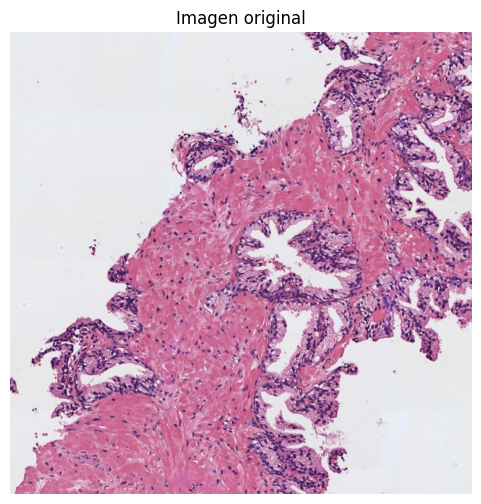

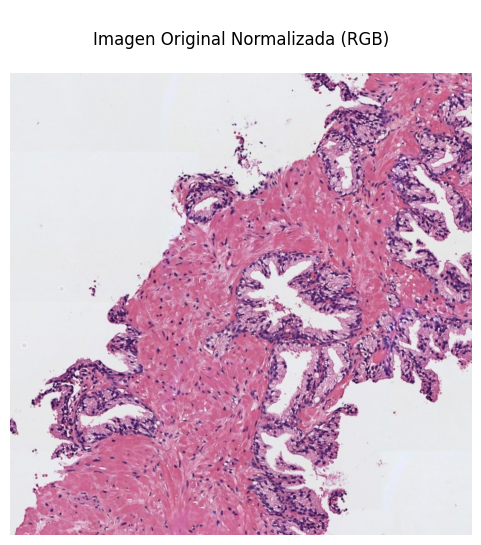

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import io
import cv2

#Leemos la imagen
img = io.imread('examen/histo_1.jpg')
rgb = img.copy()

img = cv2.imread('examen/histo_1.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(img_rgb, cmap='gray')
plt.title('Imagen original')
plt.axis('off')
plt.show()

#Normalizamos la imagen (normalizamos los datos dividiendo para 255)
rgb_p = rgb.astype('uint8')/255  

#Visualizar la imagen
fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(rgb_p)   #(img_normalized))
plt.title("\nImagen Original Normalizada (RGB)\n")
plt.axis('off')     #Opcional: oculta los ejes para una mejor visualización
plt.show()


#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

In [ ]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
# Visualizar la imagen del canal magenta

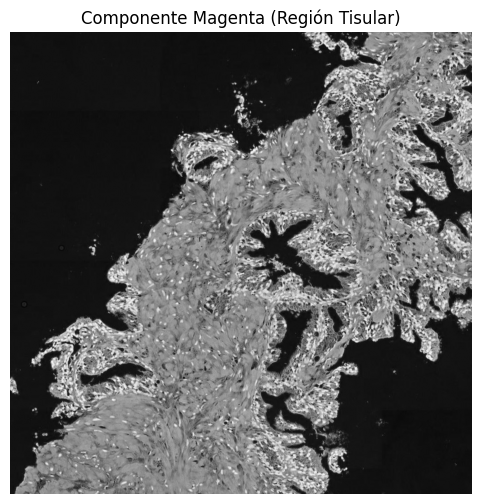

In [25]:
# Para extraer la componente Magenta en CMYK a partir de RGB:
# M = 1 - G (donde G es el canal Verde indexado en 1)
# Extraemos el canal verde de la imagen normalizada
G = rgb_p[:, :, 1]
img_magenta = 1.0 - G

# Visualizar la imagen del canal magenta
plt.figure(figsize=(6, 6))
plt.imshow(img_magenta, cmap='gray')
plt.title("Componente Magenta (Región Tisular)")
plt.axis('off')
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

In [ ]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante

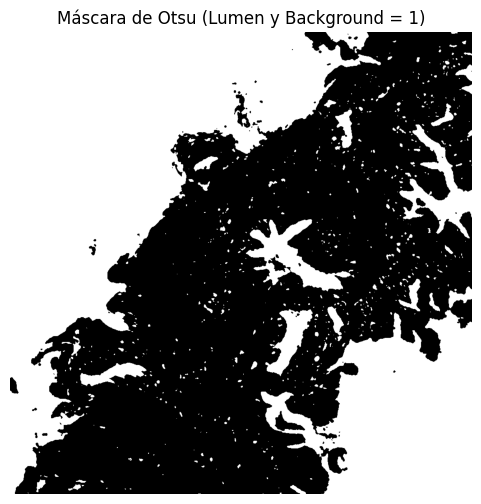

In [26]:
from skimage.filters import gaussian, threshold_otsu
from skimage import img_as_ubyte

# 1. Aplicar un filtro gaussiano de tamaño 5x5 (sigma aprox. 1 o 1.5 para suavizar ruidos pequeños)
img_blur = gaussian(img_magenta, sigma=1.2)

# 2. Convertir la imagen filtrada al rango [0-255] en formato "uint8" requerido por Otsu
img_uint8 = img_as_ubyte(img_blur)

# 3. Utilizar el método de Otsu para calcular el umbral
thresh = threshold_otsu(img_uint8)

# Queremos que el lumen (blanco) y el background (blanco) sean 1s, y el tejido (oscuro en magenta) sea 0.
# Por lo tanto, los píxeles menores al umbral en el canal magenta representarán las zonas claras.
mask_otsu = (img_uint8 < thresh).astype(np.uint8)

# Visualizar la máscara resultante
plt.figure(figsize=(6, 6))
plt.imshow(mask_otsu, cmap='gray')
plt.title("Máscara de Otsu (Lumen y Background = 1)")
plt.axis('off')
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

In [42]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizaer la máscara resultante

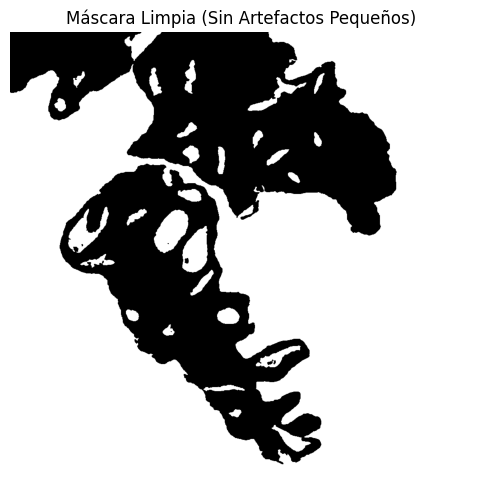

In [85]:
from skimage.morphology import remove_small_objects

# Convertir la máscara a booleana para remove_small_objects
mask_bool = mask_otsu.astype(bool)

# Eliminar aquellos objetos cuya área sea menor a 300 píxeles
mask_clean = remove_small_objects(mask_bool, max_size=300)

# Convertir de vuelta a entero para manipulación posterior
mask_clean = mask_clean.astype(np.uint8)

# Visualizar la máscara resultante
plt.figure(figsize=(6, 6))
plt.imshow(mask_clean, cmap='gray')
plt.title("Máscara Limpia (Sin Artefactos Pequeños)")
plt.axis('off')
plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

In [76]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 

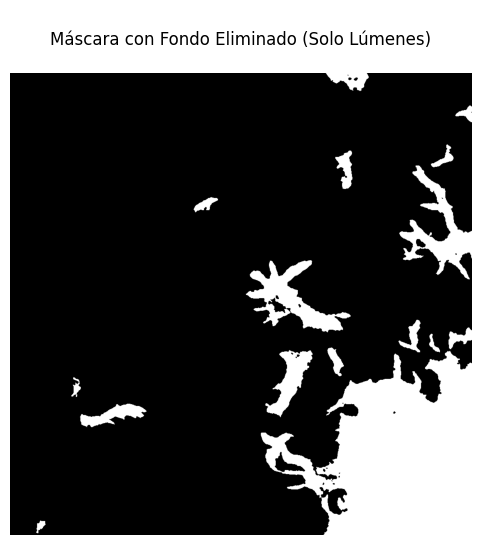

In [33]:
from skimage.segmentation import flood, flood_fill

# --- Automatización de Semillas ---
# Las esquinas de la imagen pertenecen inequívocamente al "Fondo/Background".
# Usamos flood_fill desde las esquinas superiores para aislar y apagar el fondo.

mask_lumen_only = mask_clean.copy()

# Semilla 1: Esquina superior izquierda (0,0)
if mask_lumen_only[0, 0] == 1:
    mask_lumen_only = flood_fill(mask_lumen_only, (0, 0), 0)

# Semilla 2: Esquina superior derecha (0, ancho-1) para asegurar si hay divisiones
h, w = mask_lumen_only.shape
if mask_lumen_only[0, w - 1] == 1:
    mask_lumen_only = flood_fill(mask_lumen_only, (0, w - 1), 0)

# Visualizar la máscara resultante (Solo lúmenes internos en blanco)
plt.figure(figsize=(6, 6))
plt.imshow(mask_lumen_only, cmap='gray')
plt.title("\nMáscara con Fondo Eliminado (Solo Lúmenes)\n")
plt.axis('off')
plt.show()

#### 5) Rellenar los objetos de los lúmenes

In [ ]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

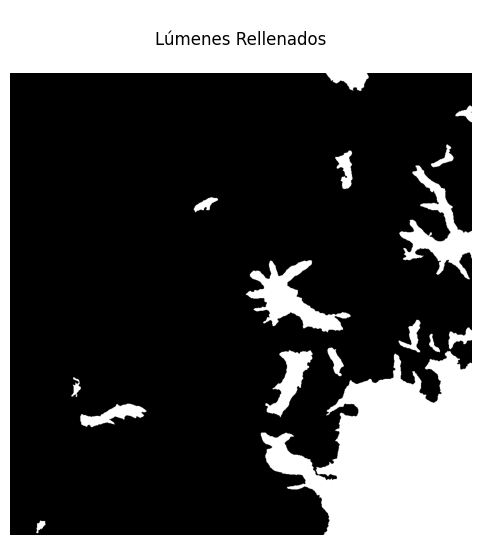

In [36]:
from scipy.ndimage import binary_fill_holes

# Rellenamos los huecos internos de las estructuras de los lúmenes
mask_filled = binary_fill_holes(mask_lumen_only).astype(np.uint8)

# Visualizar la máscara resultante
plt.figure(figsize=(6, 6))
plt.imshow(mask_filled, cmap='gray')
plt.title("\nLúmenes Rellenados\n")
plt.axis('off')
plt.show()

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

In [ ]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta

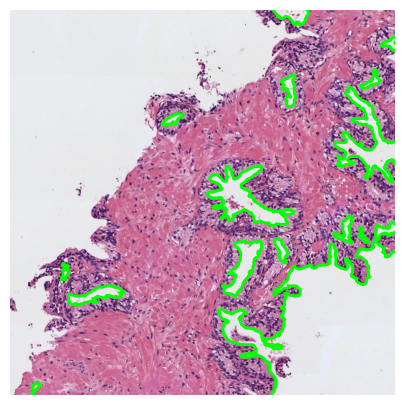

In [45]:
import matplotlib.pyplot as plt
from skimage.measure import find_contours

# Encontrar y graficar contornos directamente sobre la imagen
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)

for c in find_contours(mask_filled, level=0.5):       #utilizamos c en lugar de contour
    plt.plot(c[:, 1], c[:, 0], color='lime', linewidth=2)

plt.axis('off')
plt.show()

#### 7) Identificar y cropear el lumen más grande

In [ ]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

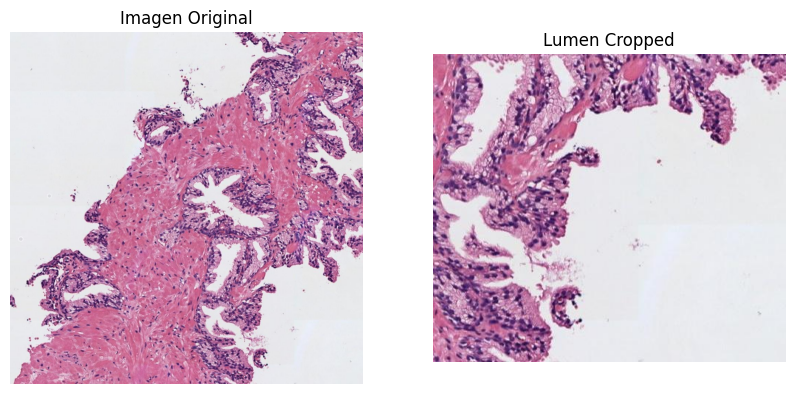

In [49]:
# CROPEAR: O cropping, que significa recortar una imagen.
# Es seleccionar una región rectangular específica de una imagen y descartar todo lo que quede fuera de esa selección.

import matplotlib.pyplot as plt
from skimage.measure import label, regionprops

# 1. Obtener límites de la región más grande directamente
minr, minc, maxr, maxc = max(regionprops(label(mask_filled)), key=lambda r: r.area).bbox

# 2. Crop dinámico en una sola línea (con margen de 10px)
crop_rgb = img_rgb[max(0, minr-10):min(img_rgb.shape[0], maxr+10), max(0, minc-10):min(img_rgb.shape[1], maxc+10)]

# 3. Visualización en paralelo compacta
figs, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_rgb), ax[0].set_title('Imagen Original'), ax[0].axis('off')
ax[1].imshow(crop_rgb), ax[1].set_title('Lumen Cropped'), ax[1].axis('off')
plt.show()

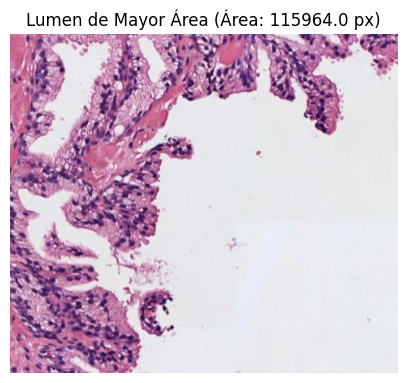

In [65]:
from skimage.measure import label, regionprops

# Etiquetar los diferentes objetos (lúmenes) de la máscara
label_img = label(mask_filled)
regions = regionprops(label_img)

# Encontrar la región con el área máxima
largest_region = max(regions, key=lambda r: r.area)

# Obtener la Bounding Box de la región más grande [min_row, min_col, max_row, max_col]
minr, minc, maxr, maxc = largest_region.bbox


# Visualizar el lumen cropeado
plt.figure(figsize=(5, 5))
plt.imshow(crop_rgb)
plt.title(f"Lumen de Mayor Área (Área: {largest_region.area} px)")
plt.axis('off')
plt.show()

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [66]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.


In [60]:
# Para extraer las propiedades geométricas puras del lumen seleccionado, 
# extraemos los atributos directamente del objeto 'largest_region' obtenido en el paso anterior.

# Definición de la Compacidad: (Perímetro^2) / Área
compacidad = (largest_region.perimeter ** 2) / largest_region.area

print("\nCaracterísticas Geométricas del Lúmen más Grande\n")
print(f"1) Área: {round(largest_region.area, 4)}")
print(f"2) Área de la bounding box: {round(largest_region.area_bbox, 4)}")
print(f"3) Área convexa: {round(largest_region.area_convex, 4)}")
print(f"4) Excentricidad: {round(largest_region.eccentricity, 4)}")
print(f"5) Diámetro equivalente: {round(largest_region.equivalent_diameter_area, 4)}")
print(f"6) Extensión (Extent): {round(largest_region.extent, 4)}")
print(f"7) Diámetro Feret: {round(largest_region.feret_diameter_max, 4)}")
print(f"8) Longitud del eje mayor: {round(largest_region.axis_major_length, 4)}")
print(f"9) Longitud del eje menor: {round(largest_region.axis_minor_length, 4)}")
print(f"10) Orientación: {round(largest_region.orientation, 4)}")
print(f"11) Perímetro: {round(largest_region.perimeter, 4)}")
print(f"12) Solidez: {round(largest_region.solidity, 4)}")
print(f"13) Compacidad: {round(compacidad, 4)}")


Características Geométricas del Lúmen más Grande

1) Área: 115964.0
2) Área de la bounding box: 190944.0
3) Área convexa: 149453.0
4) Excentricidad: 0.5155
5) Diámetro equivalente: 384.2525
6) Extensión (Extent): 0.6073
7) Diámetro Feret: 519.2774
8) Longitud del eje mayor: 448.4996
9) Longitud del eje menor: 384.3176
10) Orientación: -1.0343
11) Perímetro: 2723.1799
12) Solidez: 0.7759
13) Compacidad: 63.9484


## Imagen 2.

#### 0) Cargar una de las imágenes histológicas

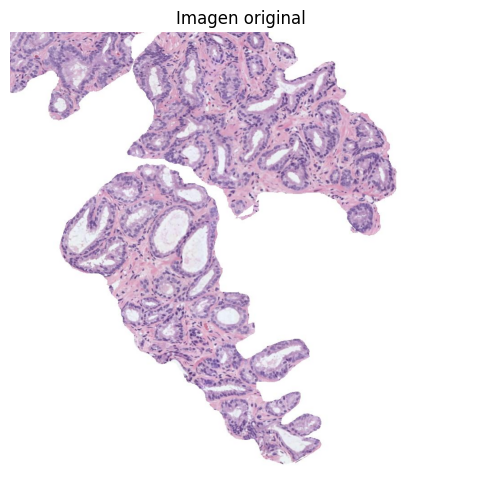

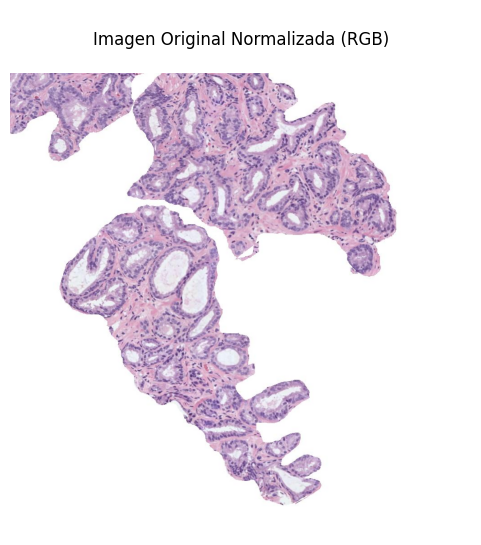

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import io
import cv2

#Leemos la imagen
img = io.imread('examen/histo_2.jpg')
rgb = img.copy()

img = cv2.imread('examen/histo_2.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(img_rgb, cmap='gray')
plt.title('Imagen original')
plt.axis('off')
plt.show()

#Normalizamos la imagen (normalizamos los datos dividiendo para 255)
rgb_p = rgb.astype('uint8')/255  

#Visualizar la imagen
fig, ax = plt.subplots(figsize=(6, 6))
plt.imshow(rgb_p)   #(img_normalized))
plt.title("\nImagen Original Normalizada (RGB)\n")
plt.axis('off')     #Opcional: oculta los ejes para una mejor visualización
plt.show()


#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

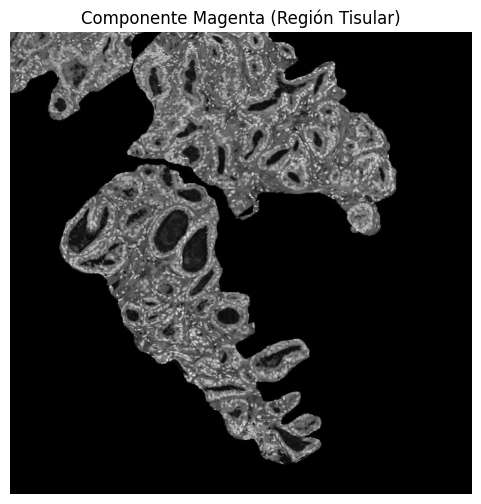

In [69]:
# Para extraer la componente Magenta en CMYK a partir de RGB:
# M = 1 - G (donde G es el canal Verde indexado en 1)
# Extraemos el canal verde de la imagen normalizada
G = rgb_p[:, :, 1]
img_magenta = 1.0 - G

# Visualizar la imagen del canal magenta
plt.figure(figsize=(6, 6))
plt.imshow(img_magenta, cmap='gray')
plt.title("Componente Magenta (Región Tisular)")
plt.axis('off')
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

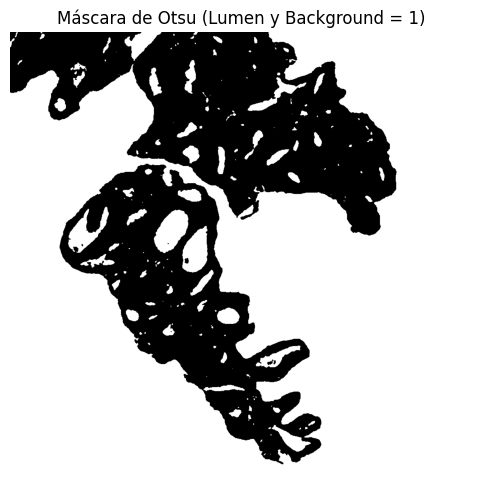

In [70]:
from skimage.filters import gaussian, threshold_otsu
from skimage import img_as_ubyte

# 1. Aplicar un filtro gaussiano de tamaño 5x5 (sigma aprox. 1 o 1.5 para suavizar ruidos pequeños)
img_blur = gaussian(img_magenta, sigma=1.2)

# 2. Convertir la imagen filtrada al rango [0-255] en formato "uint8" requerido por Otsu
img_uint8 = img_as_ubyte(img_blur)

# 3. Utilizar el método de Otsu para calcular el umbral
thresh = threshold_otsu(img_uint8)

# Queremos que el lumen (blanco) y el background (blanco) sean 1s, y el tejido (oscuro en magenta) sea 0.
# Por lo tanto, los píxeles menores al umbral en el canal magenta representarán las zonas claras.
mask_otsu = (img_uint8 < thresh).astype(np.uint8)

# Visualizar la máscara resultante
plt.figure(figsize=(6, 6))
plt.imshow(mask_otsu, cmap='gray')
plt.title("Máscara de Otsu (Lumen y Background = 1)")
plt.axis('off')
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

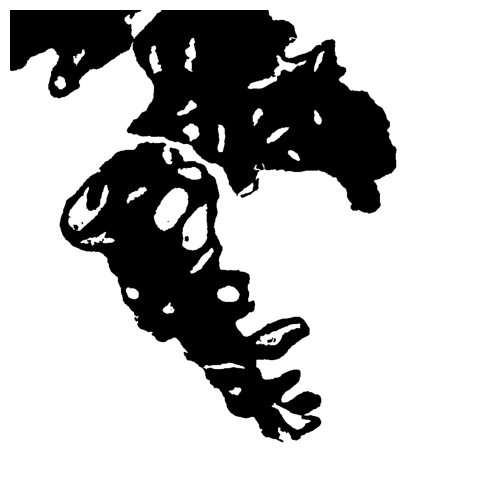

In [74]:
import matplotlib.pyplot as plt
from skimage.morphology import remove_small_objects   #skimage: librería principal (paquete completo de procesamiento de imágenes)
                                                      #morphology: analizar, procesar y contrastar las formas y estructuras geométricas

# Filtra objetos pequeños (hace la conversión a bool y a uint8 en una sola línea)
# La función remove_small_objects elimina objetos pequeños

mask_clean = remove_small_objects(mask_otsu.astype(bool), max_size=300).astype(np.uint8)

# Visualización simplificada
plt.figure(figsize=(6, 6))
plt.imshow(mask_clean, cmap='gray')
plt.axis('off')
plt.show()

### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

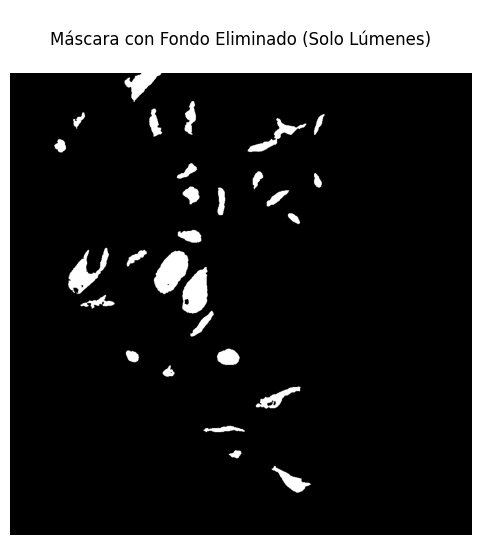

In [86]:
from skimage.segmentation import flood, flood_fill

# --- Automatización de Semillas ---
# Las esquinas de la imagen pertenecen inequívocamente al "Fondo/Background".
# Usamos flood_fill desde las esquinas superiores para aislar y apagar el fondo.

mask_lumen_only = mask_clean.copy()

# Semilla 1: Esquina superior izquierda (0,0)
if mask_lumen_only[0, 0] == 1:
    mask_lumen_only = flood_fill(mask_lumen_only, (0, 0), 0)

# Semilla 2: Esquina superior derecha (0, ancho-1) para asegurar si hay divisiones
h, w = mask_lumen_only.shape
if mask_lumen_only[0, w - 1] == 1:
    mask_lumen_only = flood_fill(mask_lumen_only, (0, w - 1), 0)

# Visualizar la máscara resultante (Solo lúmenes internos en blanco)
plt.figure(figsize=(6, 6))
plt.imshow(mask_lumen_only, cmap='gray')
plt.title("\nMáscara con Fondo Eliminado (Solo Lúmenes)\n")
plt.axis('off')
plt.show()

### 5) Rellenar los objetos de los lúmenes

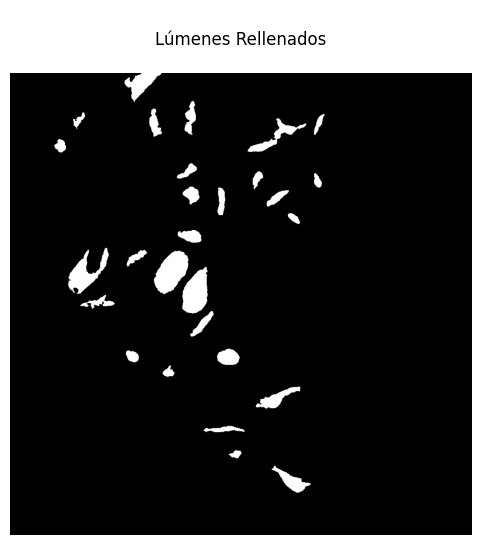

In [87]:
from scipy.ndimage import binary_fill_holes

# Rellenamos los huecos internos de las estructuras de los lúmenes
mask_filled = binary_fill_holes(mask_lumen_only).astype(np.uint8)

# Visualizar la máscara resultante
plt.figure(figsize=(6, 6))
plt.imshow(mask_filled, cmap='gray')
plt.title("\nLúmenes Rellenados\n")
plt.axis('off')
plt.show()

### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

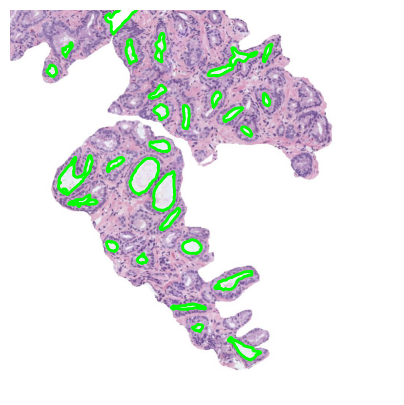

In [88]:
import matplotlib.pyplot as plt
from skimage.measure import find_contours

# Encontrar y graficar contornos directamente sobre la imagen
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)

for c in find_contours(mask_filled, level=0.5):       #utilizamos c en lugar de contour
    plt.plot(c[:, 1], c[:, 0], color='lime', linewidth=2)

plt.axis('off')
plt.show()

### 7) Identificar y cropear el lumen más grande

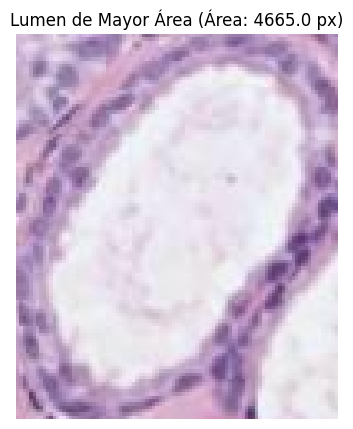

In [92]:
from skimage.measure import label, regionprops

# Etiquetar los diferentes objetos (lúmenes) de la máscara
label_img = label(mask_filled)
regions = regionprops(label_img)

# Encontrar la región con el área máxima
largest_region = max(regions, key=lambda r: r.area)

# Obtener la Bounding Box de la región más grande [min_row, min_col, max_row, max_col]
minr, minc, maxr, maxc = largest_region.bbox

# Realizar el crop sobre la imagen original RGB (añadiendo un pequeño margen opcional para visualización)
pad = 10
h_max, w_max, _ = img_rgb.shape
crop_rgb = img_rgb[max(0, minr-pad):min(h_max, maxr+pad), max(0, minc-pad):min(w_max, maxc+pad)]

# Visualizar el lumen cropeado
plt.figure(figsize=(5, 5))
plt.imshow(crop_rgb)
plt.title(f"Lumen de Mayor Área (Área: {largest_region.area} px)")
plt.axis('off')
plt.show()

### 8) Extraer 13 características geométricas del lumen recortado

In [93]:
# Para extraer las propiedades geométricas puras del lumen seleccionado, 
# extraemos los atributos directamente del objeto 'largest_region' obtenido en el paso anterior.

# Definición de la Compacidad: (Perímetro^2) / Área
compacidad = (largest_region.perimeter ** 2) / largest_region.area

print("\nCaracterísticas Geométricas del Lúmen más Grande\n")
print(f"1) Área: {round(largest_region.area, 4)}")
print(f"2) Área de la bounding box: {round(largest_region.area_bbox, 4)}")
print(f"3) Área convexa: {round(largest_region.area_convex, 4)}")
print(f"4) Excentricidad: {round(largest_region.eccentricity, 4)}")
print(f"5) Diámetro equivalente: {round(largest_region.equivalent_diameter_area, 4)}")
print(f"6) Extensión (Extent): {round(largest_region.extent, 4)}")
print(f"7) Diámetro Feret: {round(largest_region.feret_diameter_max, 4)}")
print(f"8) Longitud del eje mayor: {round(largest_region.axis_major_length, 4)}")
print(f"9) Longitud del eje menor: {round(largest_region.axis_minor_length, 4)}")
print(f"10) Orientación: {round(largest_region.orientation, 4)}")
print(f"11) Perímetro: {round(largest_region.perimeter, 4)}")
print(f"12) Solidez: {round(largest_region.solidity, 4)}")
print(f"13) Compacidad: {round(compacidad, 4)}")



Características Geométricas del Lúmen más Grande

1) Área: 4665.0
2) Área de la bounding box: 7392.0
3) Área convexa: 4841.0
4) Excentricidad: 0.8386
5) Diámetro equivalente: 77.0692
6) Extensión (Extent): 0.6311
7) Diámetro Feret: 103.9423
8) Longitud del eje mayor: 104.6876
9) Longitud del eje menor: 57.0277
10) Orientación: -0.5631
11) Perímetro: 281.2203
12) Solidez: 0.9636
13) Compacidad: 16.9528


https://github.com/moniloag-png/Fundamentos_ML/blob/main/examenPractico.ipynb
